# Interpretation XGBoost results

**Eight notebooks** cover the workflow sequence:
1. [create_datasets_yf.ipynb](01_create_datasets_yf.ipynb) : creates datasets using yfinance
2. [sentiment_feature_building](02_sentiment_feature_building.ipynb): (optional) we calculate the sentiment using finbert on financial news
3. [feature_engineering_yf](03_feature_engineering_yf.ipynb): we compute features from data to later feed into the model
4. [optimizing_xgboost](04_optimizing_xgboost.ipynb): we train a xgboost model to predict returns
5. [evaluate_xgboost](05_evaluate_xgboost.ipynb): we compare the cross-validation performance using various metrics to select the best model. 
6. `model_interpretation`(this notebook): we take a closer look at the drivers behind the best model's predictions.
7. [making_out_of_sample_predictions](07_making_out_of_sample_predictions.ipynb): we predict returns for our out-of-sample period
8. [backtest_backtrader](08_backtest_backtrader.ipynb): evaluate the historical performance of our strategy based on our predictive signals

## Imports & Settings

In [1]:
%matplotlib inline

from pathlib import Path
import warnings
from random import randint
import joblib
from itertools import product

import numpy as np
import pandas as pd

import shap

import xgboost as xgb

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

/home/sabateri/anaconda3/envs/stock-toymodel-xgboost/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
idx = pd.IndexSlice
np.random.seed(42)

In [3]:
DATA_STORE = Path('../data/nasdaq_data_yf.h5')

## Retrieve best model parameters

The results used below are created by the notebooks [gbm_trading_signals](05_gbm_trading_signals.ipynb).

In [4]:
with pd.HDFStore('data_yf.h5') as store:
    best_params = store['best_params']

In [5]:
best_params

train_length     1134.0
test_length        21.0
learning_rate       0.3
max_depth           5.0
n_estimators      500.0
alpha               0.0
boost_rounds      300.0
Name: 157, dtype: float64

## Get Training Data

In [6]:
data = pd.read_hdf('data_yf.h5', 'model_data').sort_index()
data = data.loc[idx[:, '2013':'2018'], :]

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1257216 entries, ('AAL', Timestamp('2013-01-02 00:00:00')) to ('ZYME', Timestamp('2018-12-31 00:00:00'))
Data columns (total 34 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   dollar_vol       1257216 non-null  float64
 1   dollar_vol_rank  1257216 non-null  float64
 2   rsi              1254352 non-null  float64
 3   bb_high          1253327 non-null  float64
 4   bb_low           1253323 non-null  float64
 5   NATR             1254352 non-null  float64
 6   ATR              1254352 non-null  float64
 7   PPO              1252097 non-null  float64
 8   MACD             1250451 non-null  float64
 9   sector           1257216 non-null  int64  
 10  r01              1257012 non-null  float64
 11  r05              1256196 non-null  float64
 12  r10              1255172 non-null  float64
 13  r21              1252917 non-null  float64
 14  r42              1248597 non-null  floa

## Create Binary Data

In [8]:
dates = sorted(data.index.get_level_values('date').unique())

In [9]:
train_dates = dates[-int(best_params.train_length):]

In [10]:
data = data.loc[idx[:, train_dates], :]

In [11]:
labels = sorted(data.filter(like='_fwd').columns)
features = data.columns.difference(labels).tolist()

In [12]:
lookahead = 1
label = f'r{lookahead:02}_fwd'

In [13]:
categoricals = ['year', 'month', 'sector', 'weekday']

In [14]:
# lgb_train = lgb.Dataset(data=data[features],
#                        label=data[label],
#                        categorical_feature=categoricals,
#                        free_raw_data=False)



In [15]:
# Diagnose the issue
print("Label statistics:")
print(data[label].describe())
print(f"NaN count: {data[label].isna().sum()}")
print(f"Infinite values: {np.isinf(data[label]).sum()}")
print(f"Label range: {data[label].min()} to {data[label].max()}")

# Clean the data
# Remove rows with NaN or infinite labels
mask = ~(data[label].isna() | np.isinf(data[label]))
clean_data = data[mask].copy()


Label statistics:
count    977316.000000
mean          0.000542
std           0.025444
min          -0.845324
25%          -0.009579
50%           0.000000
75%           0.010345
max           0.890909
Name: r01_fwd, dtype: float64
NaN count: 0
Infinite values: 0
Label range: -0.8453237484111146 to 0.8909089805666104


In [16]:
# Create XGBoost dataset with clean data
xgb_train = xgb.DMatrix(data=clean_data[features], label=clean_data[label], enable_categorical=True)

## Train LightGBM Model

In [17]:
params = dict(booster='gbtree',
                   objective='reg:squarederror',
                   verbosity=0)

In [18]:
train_params = ['learning_rate', 'max_depth', 'n_estimators', 'alpha']

In [19]:
params.update(best_params.loc[train_params].to_dict())
for p in ['max_depth','n_estimators', 'alpha']:
    params[p] = int(params[p])

In [20]:
params

{'booster': 'gbtree',
 'objective': 'reg:squarederror',
 'verbosity': 0,
 'learning_rate': 0.3,
 'max_depth': 5,
 'n_estimators': 500,
 'alpha': 0}

In [21]:
# lgb_model = lgb.train(params=params,
#                   train_set=lgb_train,
#                   num_boost_round=int(best_params.boost_rounds))

In [22]:
# Train the model
xgb_model = xgb.train(params=params, dtrain=xgb_train, num_boost_round=int(best_params.boost_rounds))

## Compute Feature Importance

A common approach to gaining insights into the predictions made by tree ensemble methods, such as gradient boosting or random forest models, is to attribute feature importance values to each input variable. These feature importance values can be computed on an individual basis for a single prediction or globally for an entire dataset (that is, for all samples) to gain a higher-level perspective on how the model makes predictions.

There are three primary ways to compute global feature importance values:
- Gain: This classic approach introduced by Leo Breiman in 1984 uses the total reduction of loss or impurity contributed by all splits for a given feature. The motivation is largely heuristic, but it is a commonly used method to select features.
- Split count: This is an alternative approach that counts how often a feature is used to make a split decision, based on the selection of features for this purpose based on the resultant information gain.
- Permutation: This approach randomly permutes the feature values in a test set and measures how much the model's error changes, assuming that an important feature should create a large increase in the prediction error. Different permutation choices lead to alternative implementations of this basic approach.

All gradient boosting implementations provide feature-importance scores after training as a model attribute. The `lightGBM` library provides five versions, as shown in the following list:
- total_gain and gain as its average per split
- total_cover as the number of samples per split when a feature was used
- weight as the split count from preceding values

These values are available using the trained model's .feature_importance() method with the corresponding importance_type parameter. For the best performing XGBoost model, the results are as follows (the total measures have a correlation of 0.8, as do cover and total_cover):

While the indicators for different months and years dominate, the most recent 1m return is the second-most important feature from a total_gain perspective, and is used frequently according to the weight measure, but produces low average gains as it is applied to relatively few instances on average).

In [23]:
def get_xgb_feature_importance(model, importance_type='weight'):
    """
    XGBoost importance types:
    - 'weight': number of times a feature is used to split the data (equivalent to LightGBM's 'split')
    - 'gain': average gain across all splits the feature is used in
    - 'cover': average coverage across all splits the feature is used in
    - 'total_gain': total gain across all splits the feature is used in
    - 'total_cover': total coverage across all splits the feature is used in
    """
    importance_dict = model.get_score(importance_type=importance_type)
    fi = pd.Series(importance_dict)
    return fi / fi.sum()

In [24]:
# Create comprehensive feature importance DataFrame
feature_importance = pd.DataFrame({
    'Gain': get_xgb_feature_importance(xgb_model, 'gain'),      # equivalent to 'split'
    'Weight': get_xgb_feature_importance(xgb_model, 'weight'),
    'Cover': get_xgb_feature_importance(xgb_model, 'cover')
}).fillna(0)  # Fill NaN for features not used in any splits

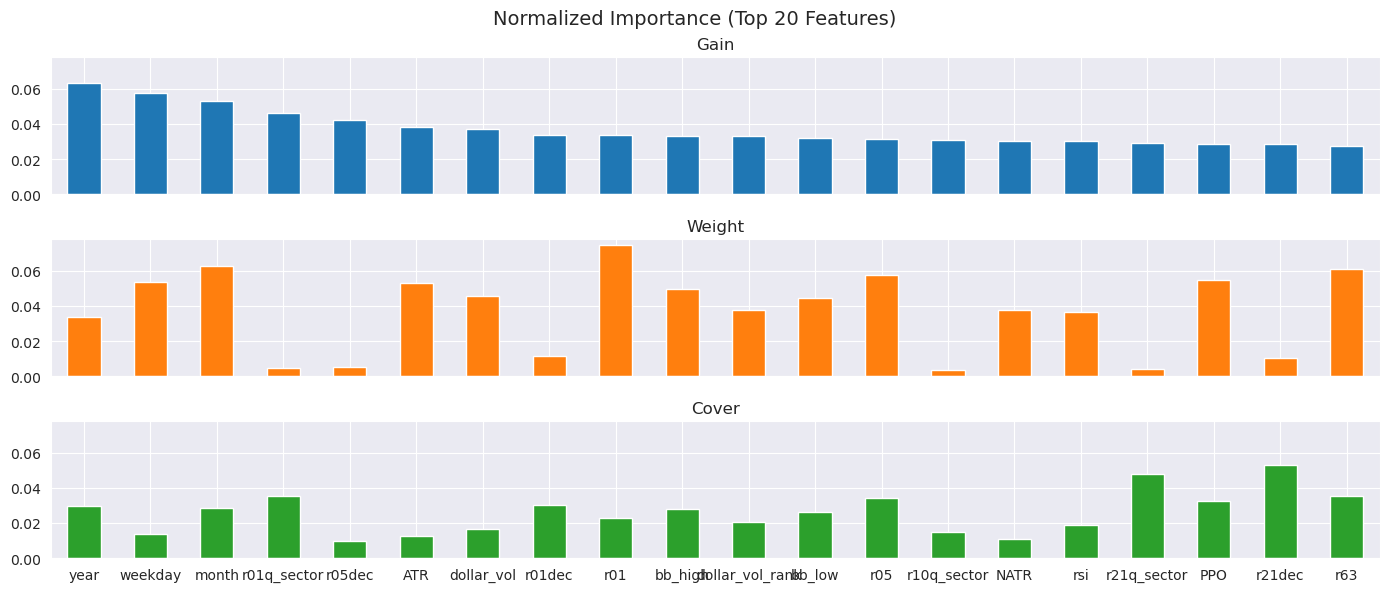

In [25]:
(feature_importance
 .nlargest(20, columns='Gain')
 .sort_values('Gain', ascending=False)
 .plot
 .bar(subplots=True,
      layout=(3, 1),
      figsize=(14, 6),
      legend=False,
      sharey=True,
      rot=0))
plt.suptitle('Normalized Importance (Top 20 Features)', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=.9)

## SHAP Values

### Summary Plot

To get a high-level overview of the feature importance across a number of samples, there are two ways to plot the SHAP values: a simple average across all samples that resembles the global feature-importance measures computed previously (as shown in the second plot), or a scatter graph to display the impact of every feature for every sample (as shown in first plot). 

The scatter plot sorts features by their total SHAP values across all samples, and then shows how each feature impacts the model output as measured by the SHAP value as a function of the feature's value, represented by its color, where red represents high and blue represents low values relative to the feature's range.

They are very straightforward to produce using a trained model of a compatible library and matching input data, as shown in the following code:

In [26]:
X = data[features].sample(n=1000)

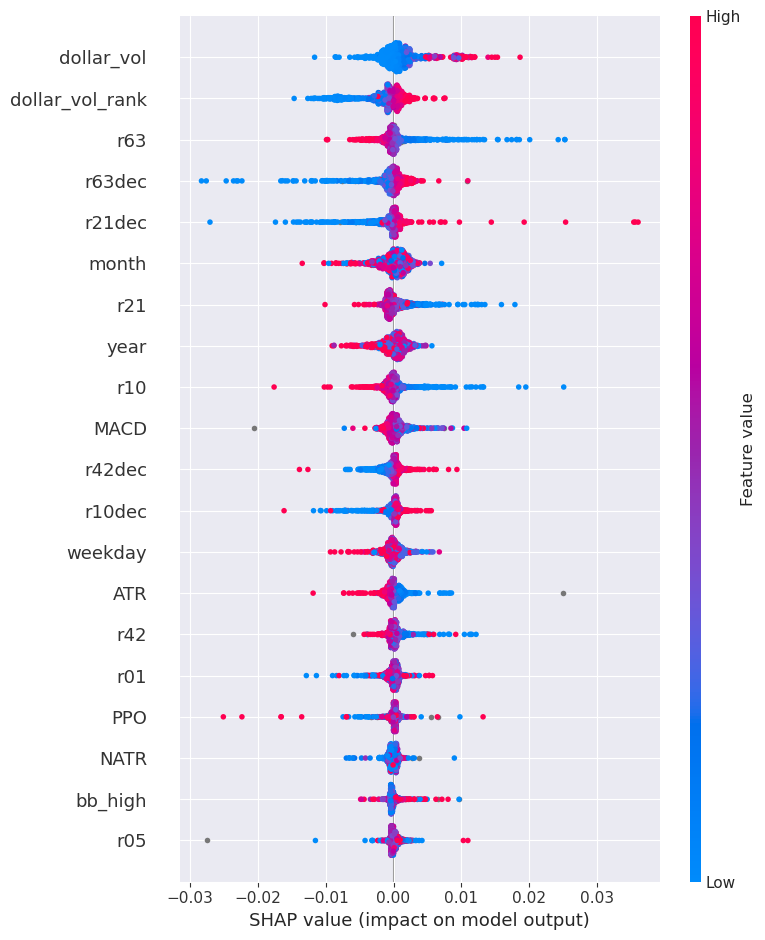

In [27]:
# load JS visualization code to notebook
shap.initjs()

# explain the model's predictions using SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X=X)

shap.summary_plot(shap_values, X, show=False)
plt.tight_layout()

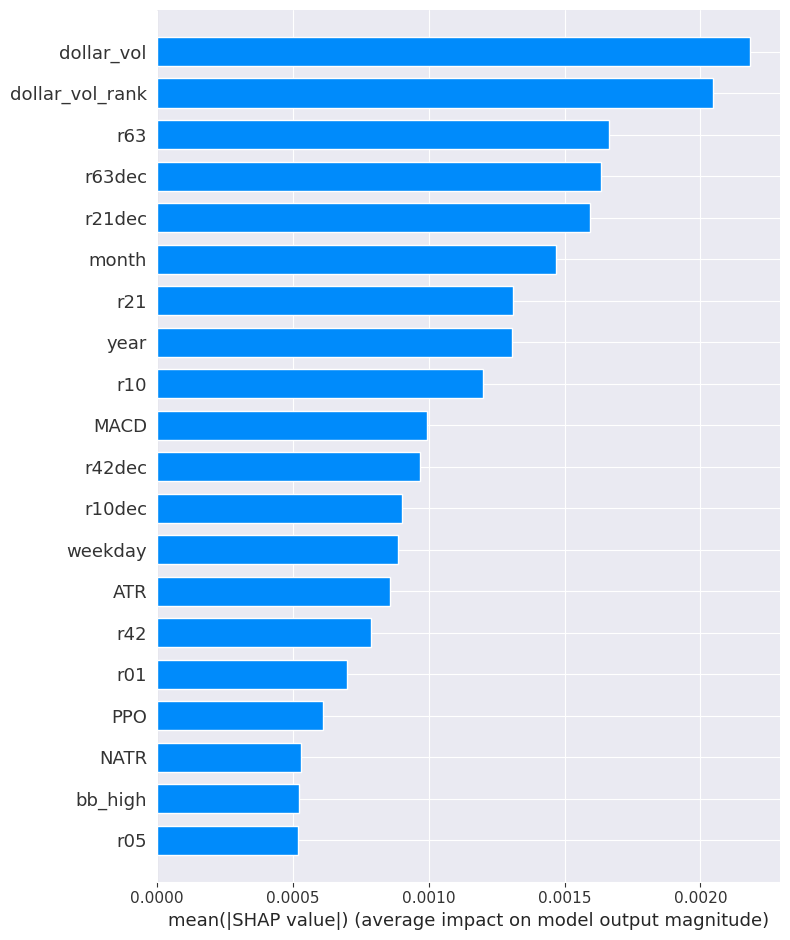

In [28]:
shap.summary_plot(shap_values, X, plot_type="bar",show=False)
plt.tight_layout()

### Feature Interaction

### Force Plots

The following force plot shows the cumulative impact of various features and their values on the model output, which in this case was 0.6, quite a bit higher than the base value of 0.13 (the average model output over the provided dataset). 

Features highlighted in red increase the output. The month being October is the most important feature and increases the output from 0.338 to 0.537, whereas the year being 2017 reduces the output. 

Hence, we obtain a detailed breakdown of how the model arrived at a specific prediction:

In [29]:
i = randint(0, len(X))
# visualize the first prediction's explanation
shap.force_plot(explainer.expected_value, shap_values[i,:], X.iloc[i,:])

We can also compute force plots for numerous data points or predictions at a time and use a clustered visualization to gain insights into how prevalent certain influence patterns are across the dataset. 

The following plot shows the force plots for the first 1,000 observations rotated by 90 degrees, stacked horizontally, and ordered by the impact of different features on the outcome for the given observation. 

The implementation uses hierarchical agglomerative clustering of data points on the feature SHAP values to identify these patterns, and displays the result interactively for exploratory analysis, as shown in the following code:

In [30]:
shap.force_plot(explainer.expected_value, shap_values[:1000,:], X.iloc[:1000])

### Interaction Plot

Lastly, SHAP values allow us to gain additional insights into the interaction effects between different features by separating these interactions from the main effects. The shap.dependence_plot  can be defined as follows. It displays how different values for 1-month returns (on the x axis) affect the outcome (SHAP value on the y axis), differentiated by 3-month returns:

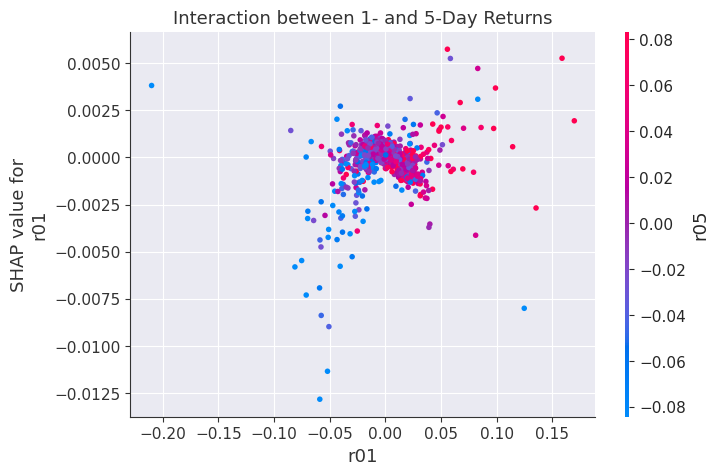

In [31]:
shap.dependence_plot(ind='r01',
                     shap_values=shap_values,
                     features=X,
                     interaction_index='r05',
                     title='Interaction between 1- and 5-Day Returns')

SHAP values provide granular feature attribution at the level of each individual prediction, and enable much richer inspection of complex models through (interactive) visualization. The SHAP summary scatterplot displayed at the beginning of this section offers much more differentiated insights than a global feature-importance bar chart. Force plots of individual clustered predictions allow for more detailed analysis, while SHAP dependence plots capture interaction effects and, as a result, provide more accurate and detailed results than partial dependence plots.

The limitations of SHAP values, as with any current feature-importance measure, concern the attribution of the influence of variables that are highly correlated because their similar impact could be broken down in arbitrary ways.